# R² threshold comparison across configurations

For each **configuration** (experiment folder), we load `train_r2_scores.csv` and `test_r2_scores.csv` from every `run_*` directory.

**Per run**, we compute the **fraction of genes** (one R² per gene in the CSV) with \(R^2 > 0.01\) or \(R^2 > 0.1\), for train and test separately — not a threshold on the run’s average R² across genes.

**Batching (threshold / bar / boxplot summaries):** runs are ordered by run index and grouped in tens. For each batch we **average each gene’s R² across those 10 runs**, then compute each proportion as the **fraction of genes** whose *batch-averaged* R² exceeds 0.01 or 0.1 (not the average of the 10 per-run gene fractions). So 100 refits → **10** batch-level values per metric per configuration (incomplete tail batch dropped).

**Where we look (you choose explicitly):** set **`EXPERIMENT_SOURCES`** in the next cell to a list of dicts. Each dict has:
- **`root`**: absolute path to a directory that **contains** your experiment subfolders (e.g. a `200genes_*` tree or `seed_gene_results`).
- **`experiments`**: list of **subdirectory names** under that root (each folder should contain `run_1`, `run_2`, …). Only these are loaded; nothing else is scanned.
- **`label_prefix`** (optional): short label for plots; defaults to the basename of `root`. Configuration keys in tables/plots are `{label_prefix}/{experiment_name}`.

**Mean \(R^2\) (overfitting):** scatter plots use **each gene in each batch of 10 runs** as a point (mean train/test \(R^2\) for that gene **within** those 10 refits), so you get \((\#\mathrm{runs}/10)\times\#\mathrm{genes}\) points per configuration. The gap boxplot still uses **genome-wide** mean \(R^2\) per batch of 10.


In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from collections import defaultdict

BATCH_SIZE = 10



def prop_above(path: str, fname: str, thr: float) -> float | None:
    """Fraction of genes (CSV rows) with R² > thr for this run/split."""
    fp = os.path.join(path, fname)
    if not os.path.isfile(fp):
        return None
    try:
        df = pd.read_csv(fp)
        if "r2" not in df.columns:
            return None
        r = df["r2"].astype(float)
        if len(r) == 0:
            return None
        return float(np.mean(r > thr))
    except Exception:
        return None


def mean_r2(path: str, fname: str) -> float | None:
    """Mean per-gene R² in one split (train or test CSV)."""
    fp = os.path.join(path, fname)
    if not os.path.isfile(fp):
        return None
    try:
        df = pd.read_csv(fp)
        if "r2" not in df.columns:
            return None
        r = df["r2"].astype(float)
        if len(r) == 0:
            return None
        return float(r.mean())
    except Exception:
        return None


def run_level_metrics(run_path: str) -> dict | None:
    """Per run: threshold proportions + mean R² (train/test)."""
    t001_tr = prop_above(run_path, "train_r2_scores.csv", 0.01)
    t01_tr = prop_above(run_path, "train_r2_scores.csv", 0.1)
    t001_te = prop_above(run_path, "test_r2_scores.csv", 0.01)
    t01_te = prop_above(run_path, "test_r2_scores.csv", 0.1)
    m_tr = mean_r2(run_path, "train_r2_scores.csv")
    m_te = mean_r2(run_path, "test_r2_scores.csv")
    if any(
        x is None
        for x in (t001_tr, t01_tr, t001_te, t01_te, m_tr, m_te)
    ):
        return None
    return {
        "prop_train_gt_001": t001_tr,
        "prop_train_gt_01": t01_tr,
        "prop_test_gt_001": t001_te,
        "prop_test_gt_01": t01_te,
        "mean_r2_train": m_tr,
        "mean_r2_test": m_te,
    }


def load_train_test_r2_per_gene(run_path: str) -> pd.DataFrame | None:
    """Per run: columns gene, r2_train, r2_test."""
    tp = os.path.join(run_path, "train_r2_scores.csv")
    sp = os.path.join(run_path, "test_r2_scores.csv")
    if not (os.path.isfile(tp) and os.path.isfile(sp)):
        return None
    try:
        a = pd.read_csv(tp)
        b = pd.read_csv(sp)
        if "gene" not in a.columns or "r2" not in a.columns:
            return None
        if "gene" not in b.columns or "r2" not in b.columns:
            return None
        m = a[["gene", "r2"]].merge(b[["gene", "r2"]], on="gene", suffixes=("_train", "_test"))
        if m.empty:
            return None
        m["r2_train"] = m["r2_train"].astype(float)
        m["r2_test"] = m["r2_test"].astype(float)
        return m[["gene", "r2_train", "r2_test"]]
    except Exception:
        return None



def gather_per_gene_per_batch_averages(
    config_label: str,
    runs: list[str],
    batch_size: int = BATCH_SIZE,
) -> pd.DataFrame:
    """
    For each configuration: group runs into consecutive batches of `batch_size`.
    Within each batch, for each gene, average train R² and test R² across those runs.

    Returns one row per (configuration, batch_id, gene) with columns
    mean_r2_train, mean_r2_test.  With 100 runs and 60 genes you get 10 * 60 points
    per configuration (genes missing in any run of the batch are dropped).
    """
    rows = []
    for b_start in range(0, len(runs), batch_size):
        chunk = runs[b_start : b_start + batch_size]
        if len(chunk) < batch_size:
            continue
        dfs = [load_train_test_r2_per_gene(rp) for rp in chunk]
        if any(d is None for d in dfs):
            continue
        parts = []
        for i, d in enumerate(dfs):
            dd = d.copy()
            dd["_run"] = i
            parts.append(dd)
        long_df = pd.concat(parts, ignore_index=True)
        g = long_df.groupby("gene", as_index=False).agg(
            mean_r2_train=("r2_train", "mean"),
            mean_r2_test=("r2_test", "mean"),
            n=("r2_train", "count"),
        )
        g = g[g["n"] == batch_size].drop(columns=["n"])
        g["batch_id"] = b_start // batch_size
        g["configuration"] = config_label
        rows.append(g)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def parse_configuration_index_fields(configuration: str) -> dict[str, object]:
    """Parse `config1/lr0.01_tau12_log1p/...`-style labels into index columns."""
    s = str(configuration).strip()
    parts = [p for p in s.split("/") if p]
    config_num = pd.NA
    mode = pd.NA
    scaling = pd.NA
    if parts:
        m = re.match(r"(?i)config(\d+)$", parts[0])
        if m:
            config_num = int(m.group(1))
    lr_blob = parts[1] if len(parts) > 1 else ""
    if lr_blob:
        toks = lr_blob.split("_")
        if len(toks) >= 3:
            if toks[-1] in ("log1p", "full"):
                scaling = toks[-1]
            mid = toks[-2]
            if mid == "tau12":
                mode = "tau12"
            elif mid == "tau":
                mode = "tau"
    return {"config_num": config_num, "mode": mode, "scaling": scaling}


def add_configuration_index_columns(
    df: pd.DataFrame, col: str = "configuration"
) -> pd.DataFrame:
    """Insert config_nu, mode, scaling immediately after `col`."""
    out = df.copy()
    meta = pd.DataFrame([parse_configuration_index_fields(x) for x in out[col]])
    meta["config_num"] = meta["config_num"].astype("Int64")
    idx = out.columns.get_loc(col) + 1
    for j, name in enumerate(["config_num", "mode", "scaling"]):
        out.insert(idx + j, name, meta[name])
    return out


def gather_run_level_proportion_batches(
    experiments: list[dict],
    r2_stats_full: dict,
    batch_size: int = BATCH_SIZE,
) -> pd.DataFrame:
    """Chunk runs in order into full batches of ``batch_size``.

    Each row is one batch: **mean of per-run** gene fractions (``prop_*`` from
    ``run_level_metrics``). Incomplete tails or batches with any failed run
    (``None``) are dropped, matching ``gather_per_gene_per_batch_averages``.
    """
    rows = []
    for exp in experiments:
        config_label = exp["root"].split("absmu/")[-1]
        n_runs = len(exp["experiments"])
        metrics = r2_stats_full[exp["root"]]
        if len(metrics) != n_runs:
            raise ValueError(
                f"Length mismatch for {config_label}: "
                f"{len(metrics)} metrics vs {n_runs} runs"
            )
        for b_start in range(0, n_runs, batch_size):
            chunk = metrics[b_start : b_start + batch_size]
            if len(chunk) < batch_size:
                chunk = metrics[b_start:]
            if any(m is None for m in chunk):
                continue
            rows.append(
                {
                    "configuration": config_label,
                    "batch_id": b_start // batch_size,
                    "prop_train_gt_001": float(
                        np.mean([m["prop_train_gt_001"] for m in chunk])
                    ),
                    "prop_train_gt_01": float(
                        np.mean([m["prop_train_gt_01"] for m in chunk])
                    ),
                    "prop_test_gt_001": float(
                        np.mean([m["prop_test_gt_001"] for m in chunk])
                    ),
                    "prop_test_gt_01": float(
                        np.mean([m["prop_test_gt_01"] for m in chunk])
                    ),
                }
            )
    return pd.DataFrame(rows)


def summarize_proportion_batches(batch_df: pd.DataFrame) -> pd.DataFrame:
    """Per configuration: mean of batch-level proportions."""
    if batch_df.empty:
        return pd.DataFrame(columns=["configuration"])
    return batch_df.groupby("configuration", as_index=False).agg(
        prop_train_gt_001_mean=("prop_train_gt_001", "mean"),
        prop_train_gt_01_mean=("prop_train_gt_01", "mean"),
        prop_test_gt_001_mean=("prop_test_gt_001", "mean"),
        prop_test_gt_01_mean=("prop_test_gt_01", "mean"),
    )





In [7]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_chrombpnet_dist_absmu"
CONFIGS = [1]
LR = 0.01

experiments = []
for cfg_num in CONFIGS:
    for config_dir in os.listdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}")):
        if "tau12" not in config_dir:
            for model_dir in os.listdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir)):
                runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, f"run_{i}"))]
                experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir), "experiments": runs})
            continue
        for model_dir in os.listdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir)):
            if model_dir == "burden":
                continue
            for prior_config in os.listdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir)):
                runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config, f"run_{i}"))]
                experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config), "experiments": runs})
                if "beta_maf_1" in os.listdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config)):
                    beta1_runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config, "beta_maf_1", f"run_{i}"))]
                    experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config, "beta_maf_1"), "experiments": beta1_runs})

            



FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_chrombpnet_dist_absmu/config1'

In [ ]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_select_annotations"
CONFIG = 1
LR = 0.01

experiments = []
for config_dir in os.listdir(EXPERIMENTS_ROOT):
    for model_dir in os.listdir(os.path.join(EXPERIMENTS_ROOT, config_dir)):
        runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, config_dir, model_dir, f"run_{i}"))]
        experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, config_dir, model_dir), "experiments": runs})
            



In [ ]:
CHROMBPNET_EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_chrombpnet_dist_absmu"
CONFIGS = [1]
LR = 0.01

for cfg_num in CONFIGS:
    for config_dir in os.listdir(os.path.join(CHROMBPNET_EXPERIMENTS_ROOT, f"config{cfg_num}")):
        if "tau12" not in config_dir:
            continue
        
        for model_dir in os.listdir(os.path.join(CHROMBPNET_EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir)):
            if "burden" in model_dir:
                continue
            for prior_config in os.listdir(os.path.join(CHROMBPNET_EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir)):
                if prior_config != "tau2_norm_prior":
                    continue
                runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(CHROMBPNET_EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config, f"run_{i}"))]
                experiments.append({"root": os.path.join(CHROMBPNET_EXPERIMENTS_ROOT, f"config{cfg_num}", config_dir, model_dir, prior_config), "experiments": runs})
    


In [ ]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations"

ABLATIONS = ["full","nowg", "norhog", "nowg_norhog"]
T = ["T", "noT"]

experiments = []
for abl in ABLATIONS:
    for t in T:
        runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, abl, t, f"run_{i}"))]
        experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, abl, t), "experiments": runs})


In [23]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/topgenes_neg_annotations_fullT"
COMMON = ["rare_common", "rare_common_maf_beta25", "common"]
PRIOR = ["dir", "norm"]
INTERCEPT = ["no_intercept", "intercept"]

experiments = []
for common in COMMON:
    for prior in PRIOR:
        for intercept in INTERCEPT:
            exp = f"tau1_{prior}_{intercept}"
            runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, common, exp, f"run_{i}"))]
            experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, common, exp), "experiments": runs})

In [3]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/topgenes_neg_annotations_fullT"
COMMON = [ "rare_common_random", "rare_common_random_maf_beta25"]
PRIOR = ["dir", "norm"]
INTERCEPT = ["no_intercept", "intercept"]

experiments = []
for common in COMMON:
    for prior in PRIOR:
        for intercept in INTERCEPT:
            exp = f"tau1_{prior}_{intercept}"
            runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, common, exp, f"run_{i}"))]
            experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, common, exp), "experiments": runs})

In [ ]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/topgenes_neg_annotations_stability"
CONFIGS = ["combined_clip5_smooth_wgpos", "control_full", "lin2_clip5", "smooth_gate", "wg_positive"]

experiments = []
for config in CONFIGS:
    runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, config, f"run_{i}"))]
    experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, config), "experiments": runs})


In [14]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/topgenes_neg_annotations_stability_random_genes"
CONFIGS = ["combined_clip5_smooth_wgpos", "control_full", "lin2_clip5", "smooth_gate", "wg_positive"]

experiments = []
for config in CONFIGS:
    runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, config, f"run_{i}"))]
    experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, config), "experiments": runs})


In [2]:
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations_fullT_priorT"
TAU = ["tau1_dir_intercept", "tau1_norm_intercept"]
T = ["prior_1_1", "prior_2_8", "prior_2_20", "prior_4_20"]

experiments = []
for tau in TAU:
    for t in T:
        runs = [f"run_{i}" for i in range(1, 11) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, tau, t, f"run_{i}"))]
        experiments.append({"root": os.path.join(EXPERIMENTS_ROOT, tau, t), "experiments": runs})

In [3]:
experiments

[{'root': '/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations_fullT_priorT/tau1_dir_intercept/prior_1_1',
  'experiments': ['run_1',
   'run_2',
   'run_3',
   'run_4',
   'run_5',
   'run_6',
   'run_7',
   'run_8',
   'run_9',
   'run_10']},
 {'root': '/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations_fullT_priorT/tau1_dir_intercept/prior_2_8',
  'experiments': ['run_1',
   'run_2',
   'run_3',
   'run_4',
   'run_5',
   'run_6',
   'run_7',
   'run_8',
   'run_9',
   'run_10']},
 {'root': '/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations_fullT_priorT/tau1_dir_intercept/prior_2_20',
  'experiments': ['run_1',
   'run_2',
   'run_3',
   'run_4',
   'run_5',
   'run_6',
   'run_7',
   'run_8',
   'run_9',
   'run_10']},
 {'root': '/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/200genes_neg_annotations_fullT_priorT/tau1_dir_intercept/prior_4_20',
  'experiments': ['run_1',
   'run_2

In [24]:
r2_stats_full = defaultdict(list)
r2_stats_batched = dict()

# key: string, value: list of dicts

for exp in experiments:
    for run in exp["experiments"]:
        run_path = os.path.join(exp["root"], run)
        r2_stats_full[exp["root"]].append(run_level_metrics(run_path))
    all_runs = [os.path.join(exp["root"], run) for run in exp["experiments"]]
    if 'absmu' in exp["root"]:
        config_label = exp["root"].split("absmu/")[-1]
    else:
        config_label = exp["root"].split("select_annotations/")[-1]
    r2_stats_batched[exp["root"]] = gather_per_gene_per_batch_averages(config_label, all_runs)


In [ ]:
r2_stats_full

defaultdict(list,
            {'/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/topgenes_neg_annotations_fullT/rare_common/tau1_dir_no_intercept': [{'prop_train_gt_001': 1.0,
               'prop_train_gt_01': 0.925,
               'prop_test_gt_001': 0.995,
               'prop_test_gt_01': 0.985,
               'mean_r2_train': 0.22377060514719715,
               'mean_r2_test': 0.23863533122663533},
              {'prop_train_gt_001': 1.0,
               'prop_train_gt_01': 0.92,
               'prop_test_gt_001': 0.995,
               'prop_test_gt_01': 0.985,
               'mean_r2_train': 0.22262864003735972,
               'mean_r2_test': 0.23728422330949767},
              {'prop_train_gt_001': 1.0,
               'prop_train_gt_01': 0.905,
               'prop_test_gt_001': 0.995,
               'prop_test_gt_01': 0.985,
               'mean_r2_train': 0.21914538347366888,
               'mean_r2_test': 0.23881077766253112},
              {'prop_train_gt_001': 1.0,
 

In [25]:
batch_df = pd.concat(r2_stats_batched.values())
batch_df

,gene,mean_r2_train,mean_r2_test,batch_id,configuration
0,ENSG00000013573,0.324704,0.349794,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
1,ENSG00000013725,0.136294,0.232062,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
2,ENSG00000022556,0.231736,0.192102,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
3,ENSG00000034239,0.105170,0.270500,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
4,ENSG00000036448,0.252545,0.135865,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
...,...,...,...,...,...
495,ENSG00000277494,0.100273,0.111835,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
496,ENSG00000280670,0.189044,0.319891,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
497,ENSG00000284713,0.101574,0.083540,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...
498,ENSG00000285082,0.066045,0.106374,0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...


In [26]:
# Per (configuration, batch_id): gene fractions above R² thresholds, plus mean train/test R² across genes (batch-level)
_tmp = batch_df.copy()
_tmp["_train_gt_001"] = _tmp["mean_r2_train"] > 0.01
_tmp["_train_gt_01"] = _tmp["mean_r2_train"] > 0.1
_tmp["_test_gt_001"] = _tmp["mean_r2_test"] > 0.01
_tmp["_test_gt_01"] = _tmp["mean_r2_test"] > 0.1
batch_proportions_r2_df = _tmp.groupby(["configuration", "batch_id"], as_index=False).agg(
    prop_train_gt_001=("_train_gt_001", "mean"),
    prop_train_gt_01=("_train_gt_01", "mean"),
    prop_test_gt_001=("_test_gt_001", "mean"),
    prop_test_gt_01=("_test_gt_01", "mean"),
    mean_r2_train=("mean_r2_train", "mean"),
    mean_r2_test=("mean_r2_test", "mean"),
)
batch_proportions_r2_df = add_configuration_index_columns(batch_proportions_r2_df)

# Run-level proportions: mean of per-run gene fractions within each batch (then mean across batches in summary_df)
run_level_prop_batch_df = gather_run_level_proportion_batches(
    experiments, r2_stats_full, batch_size=BATCH_SIZE
)
summary_df = summarize_proportion_batches(run_level_prop_batch_df)

batch_proportions_r2_df


,configuration,config_num,mode,scaling,batch_id,prop_train_gt_001,prop_train_gt_01,prop_test_gt_001,prop_test_gt_01,mean_r2_train,mean_r2_test
0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.464,0.988,0.630,0.121247,0.151313
1,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.456,0.990,0.616,0.120456,0.150443
2,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,0.998,0.440,0.988,0.608,0.117123,0.147368
3,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,0.992,0.422,0.988,0.588,0.115529,0.145514
4,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.920,0.995,0.985,0.222419,0.238404
5,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.920,0.995,0.985,0.220211,0.237489
6,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.910,0.995,0.980,0.216161,0.231726
7,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.900,0.995,0.980,0.211434,0.228208
8,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.955,1.000,0.870,0.247508,0.186256
9,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,<NA>,<NA>,<NA>,0,1.000,0.955,1.000,0.850,0.245857,0.185164


In [27]:
summary_df

,configuration,prop_train_gt_001_mean,prop_train_gt_01_mean,prop_test_gt_001_mean,prop_test_gt_01_mean
0,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.9992,0.4636,0.9890,0.6258
1,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.9984,0.4592,0.9882,0.6200
2,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.9948,0.4420,0.9856,0.6034
3,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.9898,0.4272,0.9826,0.5892
4,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,1.0000,0.9170,0.9950,0.9845
5,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,1.0000,0.9080,0.9950,0.9840
6,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.9995,0.8930,0.9955,0.9760
7,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,1.0000,0.8875,0.9950,0.9715
8,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,1.0000,0.9550,1.0000,0.8630
9,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,1.0000,0.9515,1.0000,0.8565


## Summary: mean across batches

For **proportions**, each batch value is already the **fraction of genes** after averaging each gene's R² across the runs in that batch. **summary_df** averages those batch-level values per configuration (or equals the single batch if you only have one).

In [28]:
METRICS = [
    ("prop_train_gt_001", r"Train: frac $R^2>0.01$"),
    ("prop_train_gt_01", r"Train: frac $R^2>0.1$"),
    ("prop_test_gt_001", r"Test: frac $R^2>0.01$"),
    ("prop_test_gt_01", r"Test: frac $R^2>0.1$"),
]

MEAN_R2_METRICS = [
    ("mean_r2_train", "Mean train R² (across genes)"),
    ("mean_r2_test", "Mean test R² (across genes)"),
]



In [29]:
# Plot helpers (configuration path layout: config*/lr*_{tau|tau12}_{log1p|full}/…)
_CHROMBPNET_CONFIG_RE = re.compile(r"(?i)config(\d+)")


def _chrombpnet_config_group(configuration: str) -> str:
    m = _CHROMBPNET_CONFIG_RE.search(str(configuration))
    return f"config{m.group(1)}" if m else "other"


def _plot_facet_group(configuration: str) -> str:
    return _chrombpnet_config_group(configuration)


def _short_r2_configuration_label(full_label: str) -> str:
    full_label = full_label.replace(f"{EXPERIMENTS_ROOT}/", "")
    parts = [p for p in str(full_label).split("/") if p]
    if len(parts) <= 2:
        return str(full_label)
    return "/".join(parts[2:])


def _scaling_from_configuration(configuration: str) -> str:
    """`log1p` or `full` from the lr blob token (config*/lr0.01_tau12_log1p/...)."""
    parts = [p for p in str(configuration).split("/") if p]
    lr_blob = parts[1] if len(parts) > 1 else ""
    toks = lr_blob.split("_") if lr_blob else []
    if toks and toks[-1] == "log1p":
        return "log1p"
    if toks and toks[-1] == "full":
        return "full"
    if "log1p" in configuration:
        return "log1p"
    elif "full" in configuration:
        return "full"
    return "other"


_ABLATION_BAR_RANK = {"full": 0, "nowg": 1, "norhog": 2, "nowg_norhog": 3, "burden": 4}


def _r2_bar_sort_key(configuration: str) -> tuple:
    s = str(configuration)
    parts = [p for p in s.split("/") if p]
    lr_blob = parts[1] if len(parts) > 1 else ""
    abl = "/".join(parts[2:]) if len(parts) > 2 else ""
    toks = lr_blob.split("_") if lr_blob else []
    if len(toks) >= 2 and toks[-2] == "tau12":
        tau_k = 0
    elif len(toks) >= 2 and toks[-2] == "tau":
        tau_k = 1
    else:
        tau_k = 2
    if toks and toks[-1] == "full":
        sc_k = 0
    elif toks and toks[-1] == "log1p":
        sc_k = 1
    else:
        sc_k = 2
    ab_main = abl.split("/")[0] if abl else ""
    ab_rank = _ABLATION_BAR_RANK.get(ab_main, 99)
    subabl = abl[len(ab_main) :].lstrip("/") if ab_main else abl
    return (sc_k, tau_k, ab_rank, subabl, s)


def _sort_summary_df_by_tau_then_rest(summary_df: pd.DataFrame) -> pd.DataFrame:
    return (
        summary_df.assign(_bar_order=summary_df["configuration"].map(_r2_bar_sort_key))
        .sort_values("_bar_order", kind="mergesort")
        .drop(columns=["_bar_order"])
    )


def _r2_bar_family(configuration: str) -> str:
    """``chrombpnet_dist`` (path starts with ``configK``) vs ``select_annotations``."""
    parts = [p for p in str(configuration).split("/") if p]
    if parts and re.match(r"(?i)config\d+$", parts[0]):
        return "chrombpnet_dist"
    return "select_annotations"


# Optional presets for ``plot_train_test_bars(..., bar_colors_by_family=...)``
DEFAULT_BAR_COLORS_BY_FAMILY: dict[str, tuple[str, str]] = {
    "select_annotations": ("#66c2a5", "#b2abd2"),
    "chrombpnet_dist": ("#1b7837", "#54278f"),
}
DEFAULT_BAR_FAMILY_LEGEND: dict[str, str] = {
    "select_annotations": "full select annot.",
    "chrombpnet_dist": "2 annot. (chrombpnet+dist)",
}


def _reorder_summary_df_by_bar_y_labels(
    summary_df: pd.DataFrame,
    y_label_order: list[str] | None,
    *,
    label_fn=_short_r2_configuration_label,
) -> pd.DataFrame:
    """
    Reorder rows so horizontal bar y-axis matches ``y_label_order``.

    Each list entry must match ``label_fn(configuration)`` for that row
    (default: same strings as ``_short_r2_configuration_label``).
    Rows not listed are appended at the end in their original order.
    """
    if summary_df.empty or not y_label_order:
        return summary_df
    tmp = summary_df.copy().reset_index(drop=True)
    tmp["_yl"] = tmp["configuration"].map(label_fn)
    picked: list[int] = []
    used: set[int] = set()
    for lab in y_label_order:
        for idx in tmp.index:
            if idx in used:
                continue
            if tmp.at[idx, "_yl"] == lab:
                picked.append(idx)
                used.add(idx)
    rest = [i for i in tmp.index if i not in used]
    out = tmp.loc[picked + rest].drop(columns=["_yl"])
    return out.reset_index(drop=True)




## Plots




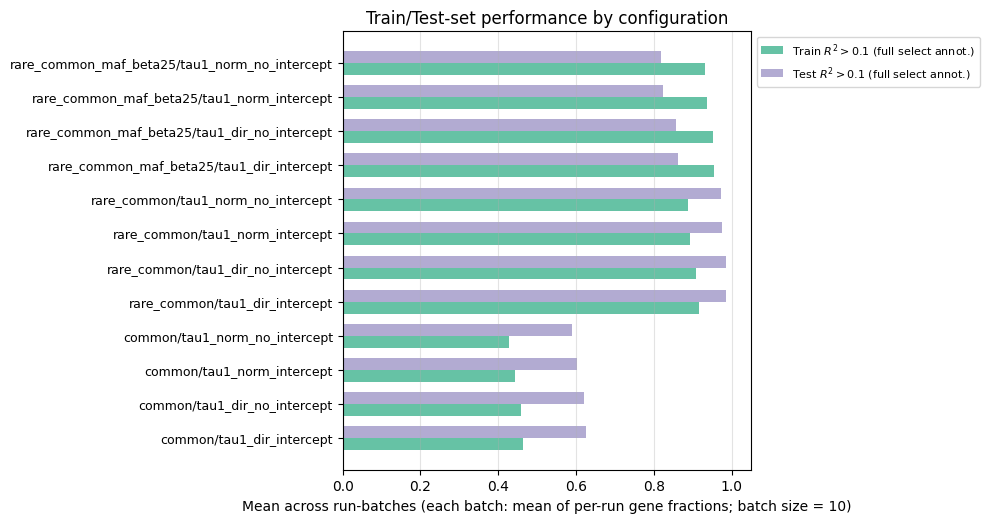

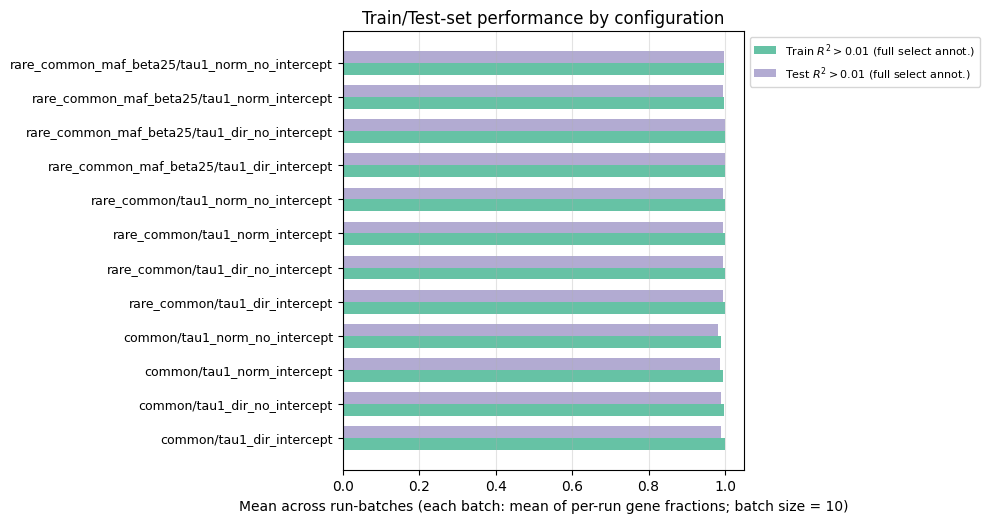

In [30]:
def plot_train_test_bars(
    summary_df: pd.DataFrame,
    figsize=(10, 5),
    thresh=0.1,
    split_by: str | list[str] | None = None,
    split_order: dict[str, list[str]] | None = None,
    split_label_map: dict[str, str] | None = None,
    split_value_fn: dict[str, callable] | None = None,
    bar_order: list[str] | None = None,
    y_label_order: list[str] | None = None,
    bar_colors_by_family: dict[str, tuple[str, str]] | None = None,
    bar_family_legend: dict[str, str] | None = None,
    bar_family_fn=None,
    # Backward-compat aliases for older calls
    split_by_chrombpnet_config: bool | None = None,
    split_by_scaling: bool | None = None,
):
    """
    Generic train/test bar plot with optional faceting.

    split_by:
        None (default) => one combined plot.
        String or list of strings describing how to split into multiple plots.
        Supported built-ins: "scaling", "chrombpnet_config".
        Also accepts existing columns in ``summary_df``.

    split_order:
        Optional dict ``{split_key: [value1, value2, ...]}`` controlling group order.

    split_label_map:
        Optional dict ``{split_key: pretty_label}`` used in subplot title suffixes.

    split_value_fn:
        Optional dict ``{split_key: fn(configuration_str) -> value}`` for custom split keys.

    bar_order / y_label_order:
        Optional manual y-axis order using short labels from
        ``_short_r2_configuration_label(configuration)``.

    Notes:
        ``split_by_chrombpnet_config`` and ``split_by_scaling`` are retained for
        backward compatibility and are translated into ``split_by`` when provided.
    """
    if summary_df.empty:
        return

    def _normalize_split_keys() -> list[str]:
        if split_by is None:
            keys: list[str] = []
            if split_by_scaling:
                keys.append("scaling")
            if split_by_chrombpnet_config:
                keys.append("chrombpnet_config")
            return keys
        if isinstance(split_by, str):
            return [split_by]
        return list(split_by)

    def _resolve_split_series(sdf: pd.DataFrame, key: str) -> pd.Series:
        if key in sdf.columns:
            return sdf[key].astype(str)
        if key == "scaling":
            return sdf["configuration"].map(_scaling_from_configuration).astype(str)
        if key in {"chrombpnet_config", "plot_facet_group", "config_group"}:
            return sdf["configuration"].map(_plot_facet_group).astype(str)
        if split_value_fn and key in split_value_fn:
            return sdf["configuration"].map(split_value_fn[key]).astype(str)
        raise ValueError(
            f"Unsupported split key '{key}'. Use a column name, a built-in key, or provide split_value_fn."
        )

    def _ordered_unique(values: pd.Series, preferred: list[str] | None = None) -> list[str]:
        seen = set()
        uniq = []
        for v in values.tolist():
            if v not in seen:
                uniq.append(v)
                seen.add(v)
        if not preferred:
            return uniq
        out = [v for v in preferred if v in seen]
        out.extend([v for v in uniq if v not in set(out)])
        return out

    selected_bar_order = bar_order if bar_order is not None else y_label_order

    def _one(sdf: pd.DataFrame, title_suffix: str = "") -> None:
        sub = _sort_summary_df_by_tau_then_rest(sdf).copy()
        if selected_bar_order:
            sub = _reorder_summary_df_by_bar_y_labels(sub, selected_bar_order)
        n = len(sub)
        if n == 0:
            return
        y = np.arange(n)
        h = 0.35
        if thresh == 0.01:
            x1 = sub["prop_train_gt_001_mean"].values
            x2 = sub["prop_test_gt_001_mean"].values
        else:
            x1 = sub["prop_train_gt_01_mean"].values
            x2 = sub["prop_test_gt_01_mean"].values
        fig_w, _ = figsize
        fig_h = max(5.0, 0.32 * n + 1.5)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        if bar_colors_by_family:
            fn = bar_family_fn or _r2_bar_family
            fam = sub["configuration"].map(fn)
            default_pair = ("#4daf4a", "#984ea3")
            c_train = [bar_colors_by_family.get(f, default_pair)[0] for f in fam]
            c_test = [bar_colors_by_family.get(f, default_pair)[1] for f in fam]
            ax.barh(y - h / 2, x1, height=h, color=c_train)
            ax.barh(y + h / 2, x2, height=h, color=c_test)
            leg_names = bar_family_legend or {}
            handles = []
            for fk in fam.unique():
                if fk not in bar_colors_by_family:
                    continue
                tr, te = bar_colors_by_family[fk]
                pretty = leg_names.get(fk, str(fk))
                handles.append(Patch(facecolor=tr, label=fr"Train $R^2>{thresh}$ ({pretty})"))
                handles.append(Patch(facecolor=te, label=fr"Test $R^2>{thresh}$ ({pretty})"))
            ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
        else:
            ax.barh(y - h / 2, x1, height=h, label=fr"Train: $R^2>{thresh}$", color="#4daf4a")
            ax.barh(y + h / 2, x2, height=h, label=fr"Test: $R^2>{thresh}$", color="#984ea3")
            ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

        ax.set_yticks(y)
        ax.set_yticklabels(sub["configuration"].map(_short_r2_configuration_label), fontsize=9)
        ax.set_xlabel(
            f"Mean across run-batches (each batch: mean of per-run gene fractions; batch size = {BATCH_SIZE})"
        )
        t = "Train/Test-set performance by configuration"
        ax.set_title(f"{title_suffix} — {t}" if title_suffix else t)
        ax.set_xlim(0, 1.05)
        ax.grid(axis="x", alpha=0.35)
        plt.tight_layout()
        plt.show()

    split_keys = _normalize_split_keys()
    split_order = split_order or {}
    split_label_map = split_label_map or {
        "scaling": "Scaling",
        "chrombpnet_config": "Config group",
    }

    # Start from one chunk and refine by each requested split dimension in order.
    chunks: list[tuple[str, pd.DataFrame]] = [("", summary_df.copy())]
    for split_key in split_keys:
        next_chunks: list[tuple[str, pd.DataFrame]] = []
        for title_prefix, sdf in chunks:
            vals = _resolve_split_series(sdf, split_key)
            ordered_vals = _ordered_unique(vals, split_order.get(split_key))
            label_key = split_label_map.get(split_key, split_key)
            for val in ordered_vals:
                sub = sdf.loc[vals == val]
                if sub.empty:
                    continue
                part = f"{label_key}: {val}"
                suffix = f"{title_prefix} — {part}" if title_prefix else part
                next_chunks.append((suffix, sub))
        chunks = next_chunks

    for title_suffix, sdf in chunks:
        _one(sdf, title_suffix=title_suffix)


BAR_ORDER = [
    "lr0.01_config1_full/nowg_norhog",
    "nowg_norhog/tau2_norm_prior",
    "lr0.01_config1_full/nowg",
    "nowg/tau2_norm_prior",
    "lr0.01_config1_full/norhog",
    "norhog/tau2_norm_prior",
    "lr0.01_config1_full/full",
    "full/tau2_norm_prior",
]

plot_train_test_bars(
    summary_df,
    bar_order=BAR_ORDER,
    bar_colors_by_family=DEFAULT_BAR_COLORS_BY_FAMILY,
    bar_family_legend=DEFAULT_BAR_FAMILY_LEGEND,
)
plot_train_test_bars(
    summary_df,
    thresh=0.01,
    bar_order=BAR_ORDER,
    bar_colors_by_family=DEFAULT_BAR_COLORS_BY_FAMILY,
    bar_family_legend=DEFAULT_BAR_FAMILY_LEGEND,
)

# Example: custom split key + order
# plot_train_test_bars(
#     summary_df,
#     split_by=["scaling", "chrombpnet_config"],
#     split_order={"scaling": ["full", "log1p", "other"]},
#     bar_order=BAR_ORDER,
# )


# Average R2

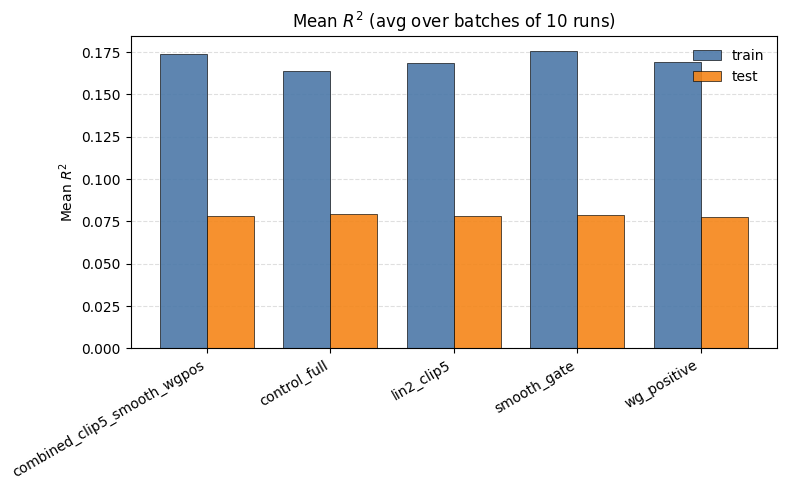

In [22]:
# Plot average r2 per gene for different configurations
# data in batch_proportions_r2_df -- mean_r2_train, mean_r2_test columns
# (one row per batch of BATCH_SIZE runs; each "mean" is already averaged across genes)

def plot_mean_r2_per_configuration(
    df: pd.DataFrame,
    *,
    figsize: tuple[float, float] | None = None,
    train_color: str = "#4c78a8",
    test_color: str = "#f58518",
    title: str | None = None,
):
    need = {"configuration", "mean_r2_train", "mean_r2_test"}
    if df.empty or not need.issubset(df.columns):
        print(f"Expected columns {need} in batch_proportions_r2_df; got {list(df.columns)}")
        return

    ordered_configs = (
        df[["configuration"]]
        .drop_duplicates()
        .assign(_k=lambda x: x["configuration"].map(_r2_bar_sort_key))
        .sort_values("_k", kind="mergesort")["configuration"]
        .tolist()
    )
    labels = [_short_r2_configuration_label(c) for c in ordered_configs]

    def _agg(col):
        means = []
        for c in ordered_configs:
            vals = df.loc[df["configuration"] == c, col].dropna().values
            if len(vals) == 0:
                means.append(np.nan)
                continue
            means.append(float(np.mean(vals)))
            
        return np.array(means)

    train_mean = _agg("mean_r2_train")
    test_mean = _agg("mean_r2_test")

    n = len(ordered_configs)
    if figsize is None:
        figsize = (max(8.0, 0.75 * n + 2.0), 5.0)
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(n)
    width = 0.38

    ax.bar(
        x - width / 2, train_mean, width,
        color=train_color, alpha=0.9, label="train",
        edgecolor="black", linewidth=0.5,
        capsize=3, error_kw=dict(elinewidth=0.8, ecolor="black"),
    )
    ax.bar(
        x + width / 2, test_mean, width,
        color=test_color, alpha=0.9, label="test",
        edgecolor="black", linewidth=0.5,
        capsize=3, error_kw=dict(elinewidth=0.8, ecolor="black"),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel(r"Mean $R^2$")
    if title is None:
        title = r"Mean $R^2$ (avg over batches of {} runs)".format(BATCH_SIZE)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    plt.show()


plot_mean_r2_per_configuration(batch_proportions_r2_df)


## Train vs test mean \(R^2\) (overfitting)

**Scatter (gene-level):** each point is one **gene × run-batch**; coordinates are mean train and test \(R^2\) for that gene after averaging over the `BATCH_SIZE` runs in that batch (`batch_df`).

**Scatter (batch-level):** one point per **(configuration, batch_id)** using genome-wide mean train/test \(R^2\) in `batch_proportions_r2_df`.

**Gap boxplots:** distribution of \(\bar{R}^2_\mathrm{train} - \bar{R}^2_\mathrm{test}\) over gene × batch points (same as gene-level scatter).


/scratch/ipykernel_1064085/4062059460.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


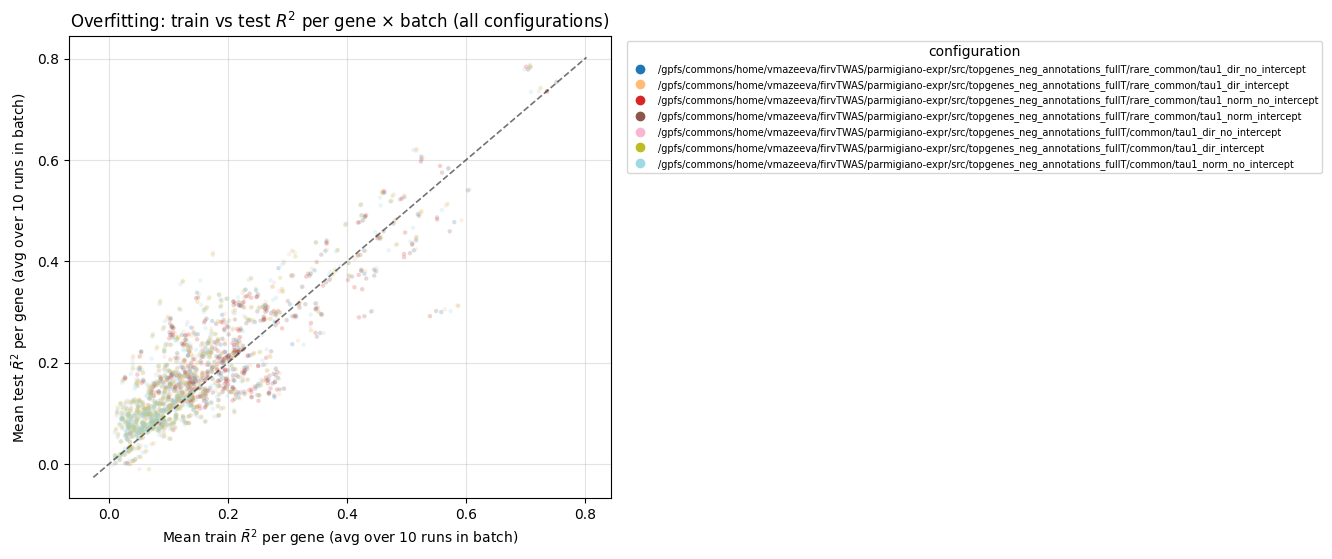

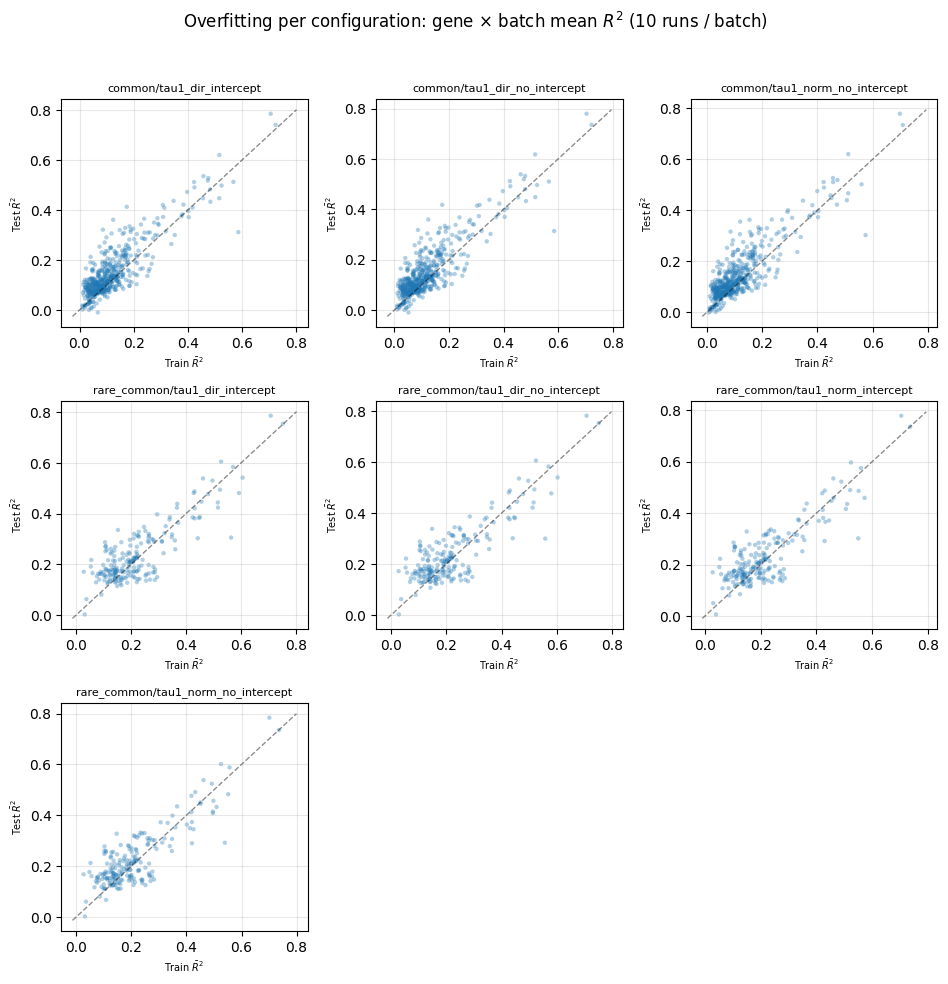

/scratch/ipykernel_1064085/4062059460.py:146: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


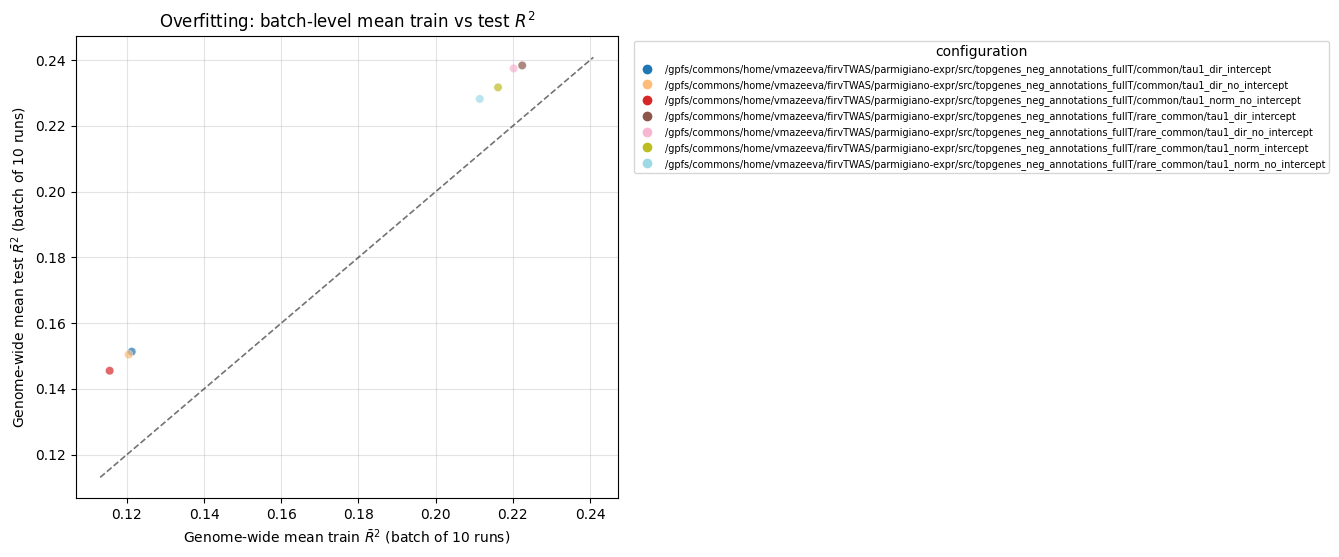

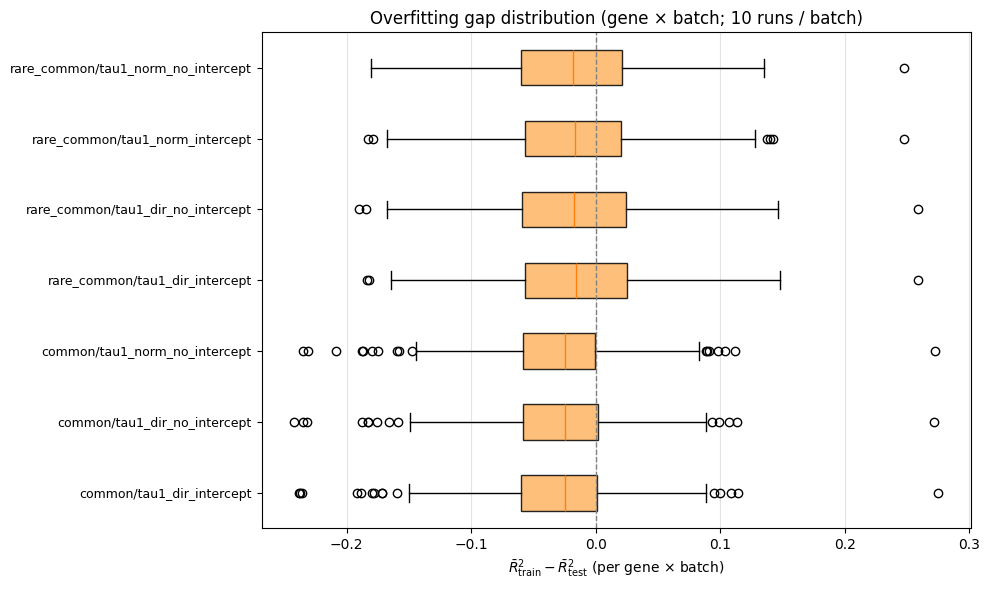

In [ ]:
def plot_train_vs_test_mean_r2_overview(gene_df: pd.DataFrame, figsize=(7, 6)):
    """Scatter: each point = one gene × run-batch; axes = mean train vs mean test R² within that batch."""
    need = {"mean_r2_train", "mean_r2_test", "configuration"}
    if gene_df.empty or not need.issubset(gene_df.columns):
        print("No gene-level batch data; build batch_df first.")
        return
    sub = gene_df.dropna(subset=["mean_r2_train", "mean_r2_test"]).copy()
    if sub.empty:
        print("No data.")
        return
    cats = sub["configuration"].astype(str)
    codes, uniques = pd.factorize(cats)
    n = len(uniques)
    cmap = plt.cm.tab20
    norm = plt.Normalize(vmin=0, vmax=max(n - 1, 0))
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        sub["mean_r2_train"],
        sub["mean_r2_test"],
        c=codes,
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.22,
        edgecolors="none",
    )
    lo = float(min(sub["mean_r2_train"].min(), sub["mean_r2_test"].min()))
    hi = float(max(sub["mean_r2_train"].max(), sub["mean_r2_test"].max()))
    pad = 0.02 * max(hi - lo, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1.2, alpha=0.55, label="y = x")
    ax.set_aspect("auto")
    ax.set_xlabel(rf"Mean train $\bar{{R}}^2$ per gene (avg over {BATCH_SIZE} runs in batch)")
    ax.set_ylabel(rf"Mean test $\bar{{R}}^2$ per gene (avg over {BATCH_SIZE} runs in batch)")
    ax.set_title("Overfitting: train vs test $R^2$ per gene × batch (all configurations)")
    ax.grid(alpha=0.35)
    handles = [
        mlines.Line2D(
            [], [], color=cmap(norm(i)), marker="o", linestyle="", markersize=6, label=u
        )
        for i, u in enumerate(uniques)
    ]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7,
        title="configuration",
    )
    plt.tight_layout()
    plt.show()


def plot_train_vs_test_mean_r2_facets(gene_df: pd.DataFrame, ncols: int = 3, figsize_per: float = 3.2):
    """Faceted scatter: one panel per configuration (gene × batch points)."""
    if gene_df.empty or not {"mean_r2_train", "mean_r2_test"}.issubset(gene_df.columns):
        return
    cfgs = sorted(gene_df["configuration"].unique(), key=_r2_bar_sort_key)
    n = len(cfgs)
    if n == 0:
        return
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * figsize_per, nrows * figsize_per),
        squeeze=False,
    )
    for idx, cfg in enumerate(cfgs):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sub = gene_df[gene_df["configuration"] == cfg]
        ax.scatter(
            sub["mean_r2_train"],
            sub["mean_r2_test"],
            alpha=0.35,
            s=10,
            edgecolors="none",
        )
        lo = float(min(sub["mean_r2_train"].min(), sub["mean_r2_test"].min()))
        hi = float(max(sub["mean_r2_train"].max(), sub["mean_r2_test"].max()))
        pad = 0.02 * max(hi - lo, 1e-6)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, alpha=0.45)
        ax.set_aspect("auto")
        ax.set_title(_short_r2_configuration_label(cfg), fontsize=8)
        ax.set_xlabel(r"Train $\bar{R}^2$", fontsize=7)
        ax.set_ylabel(r"Test $\bar{R}^2$", fontsize=7)
        ax.grid(alpha=0.3)
    for j in range(len(cfgs), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_visible(False)
    fig.suptitle(rf"Overfitting per configuration: gene × batch mean $R^2$ ({BATCH_SIZE} runs / batch)", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_batch_genome_wide_train_vs_test(
    perf_df: pd.DataFrame,
    figsize=(7, 6),
):
    """Each point = one (configuration, batch_id): genome-wide mean train vs test R² in that run-batch."""
    need = {"mean_r2_train", "mean_r2_test", "configuration"}
    if perf_df.empty or not need.issubset(perf_df.columns):
        print("No batch_proportions_r2_df; re-run the batch summary cell.")
        return
    sub = perf_df.dropna(subset=["mean_r2_train", "mean_r2_test"]).copy()
    if sub.empty:
        return
    cats = sub["configuration"].astype(str)
    codes, uniques = pd.factorize(cats)
    cmap = plt.cm.tab20
    norm = plt.Normalize(vmin=0, vmax=max(len(uniques) - 1, 0))
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        sub["mean_r2_train"],
        sub["mean_r2_test"],
        c=codes,
        cmap=cmap,
        norm=norm,
        s=36,
        alpha=0.7,
        edgecolors="white",
        linewidths=0.3,
    )
    lo = float(min(sub["mean_r2_train"].min(), sub["mean_r2_test"].min()))
    hi = float(max(sub["mean_r2_train"].max(), sub["mean_r2_test"].max()))
    pad = 0.02 * max(hi - lo, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1.2, alpha=0.55, label="y = x")
    ax.set_aspect("auto")
    ax.set_xlabel(rf"Genome-wide mean train $\bar{{R}}^2$ (batch of {BATCH_SIZE} runs)")
    ax.set_ylabel(rf"Genome-wide mean test $\bar{{R}}^2$ (batch of {BATCH_SIZE} runs)")
    ax.set_title("Overfitting: batch-level mean train vs test $R^2$")
    ax.grid(alpha=0.35)
    handles = [
        mlines.Line2D(
            [], [], color=cmap(norm(i)), marker="o", linestyle="", markersize=6, label=u
        )
        for i, u in enumerate(uniques)
    ]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7,
        title="configuration",
    )
    plt.tight_layout()
    plt.show()


def plot_mean_r2_gap_boxplot(
    batch_df: pd.DataFrame,
    figsize=(10, 6),
    split_by_chrombpnet_config: bool = True,
):
    """Distribution of (train − test) batch-averaged R² per gene, by configuration."""
    if batch_df.empty or not {"mean_r2_train", "mean_r2_test"}.issubset(batch_df.columns):
        return

    def _one(bdf: pd.DataFrame, title_suffix: str = "") -> None:
        sub = bdf.dropna(subset=["mean_r2_train", "mean_r2_test"]).copy()
        if sub.empty:
            return
        sub = sub.copy()
        sub["gap_train_minus_test"] = sub["mean_r2_train"] - sub["mean_r2_test"]
        cfgs = sorted(sub["configuration"].unique(), key=_r2_bar_sort_key)
        tick_lbls = [_short_r2_configuration_label(g) for g in cfgs]
        data = [sub.loc[sub["configuration"] == g, "gap_train_minus_test"].values for g in cfgs]
        n = len(cfgs)
        fig_w, _ = figsize
        fig_h = max(6.0, 0.35 * n + 1.5)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        bp = ax.boxplot(data, vert=False, tick_labels=tick_lbls, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("#fdb462")
            patch.set_alpha(0.85)
        ax.axvline(0, color="gray", ls="--", lw=1)
        ax.set_xlabel(r"$\bar{R}^2_\mathrm{train} - \bar{R}^2_\mathrm{test}$ (per gene × batch)")
        base = f"Overfitting gap distribution (gene × batch; {BATCH_SIZE} runs / batch)"
        ax.set_title(f"{title_suffix} — {base}" if title_suffix else base)
        ax.grid(axis="x", alpha=0.35)
        ax.tick_params(axis="y", labelsize=9)
        plt.tight_layout()
        plt.show()

    if split_by_chrombpnet_config:
        grp = batch_df["configuration"].map(_plot_facet_group)
        keys = sorted(grp.unique())
        if len(keys) > 1:
            for k in keys:
                sub = batch_df.loc[grp == k]
                if not sub.empty:
                    _one(sub, title_suffix=k)
            return
        if len(keys) == 1 and keys[0] != "other":
            _one(batch_df.loc[grp == keys[0]], title_suffix=keys[0])
            return
    _one(batch_df)


plot_train_vs_test_mean_r2_overview(batch_df)
plot_train_vs_test_mean_r2_facets(batch_df)
plot_batch_genome_wide_train_vs_test(batch_proportions_r2_df)
plot_mean_r2_gap_boxplot(batch_df)

